<a href="https://colab.research.google.com/github/bish-ai/Bishal.py/blob/main/quadratic_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from langgraph.graph import StateGraph, START ,END
from typing import TypedDict , Literal

In [2]:
class QuadState(TypedDict):
  a:int
  b:int
  c:int
  equation :str
  discriminant :float
  result : str

In [12]:
def show_equation(state: QuadState):
  equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]} = 0'
  print(f'The equation is: {equation}')
  return {'equation': equation}

In [13]:
def show_equation(state: QuadState):
  equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]} = 0'
  print(f'The equation is: {equation}')
  return {'equation': equation}

graph = StateGraph(QuadState)
graph.add_node('show_equation', show_equation)

In [22]:
def calculate_discriminant(state:QuadState):
 discriminant=state['b']^2 -4*state['a']+state['c']
 return {'discriminant':discriminant}

In [37]:
def real_roots(state:QuadState):
  discriminant=state['discriminant']
  if discriminant>0:
    root1=-(state['b']**2-discriminant**0.5)/(2*state['a'])
    root2= -(state['b']**2+discriminant**0.5)/(2*state['a'])
  result= f"The roots are{root1} and {root2}"
  return {'result':result}

In [38]:
def repeated_roots(state:QuadState):
  discriminant=state['discriminant']
  if discriminant ==0:
    root=(-state['b'])//2*state['a']
    result=f"The root is {root}"
  return {'result':result}

In [58]:
def neg_roots(state:QuadState):
  discriminant=state["discriminant"]
  if discriminant<0:
    result=f"there are no real roots"
  return {'result' :result}

In [59]:
def check_condition(state:QuadState)->Literal["real_roots","repeated_roots","neg_roots"]:
  if state['discriminant']>0:
    return 'real_roots'
  elif state['discriminant']==0:
    return 'repeated_roots'
  else:
    return 'neg_roots'


In [61]:
graph =StateGraph(QuadState)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_node("real_roots",real_roots)
graph.add_node('neg_roots',neg_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('neg_roots',END)
graph.add_edge('repeated_roots',END)
workflow =graph.compile()

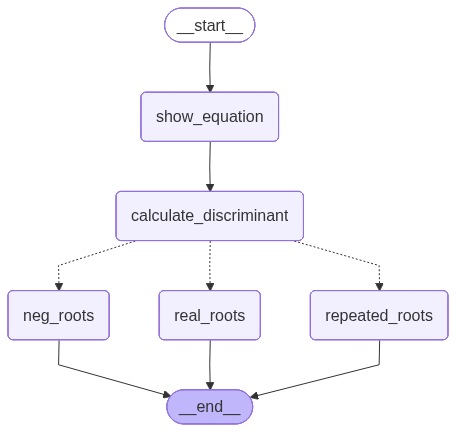

In [62]:
workflow

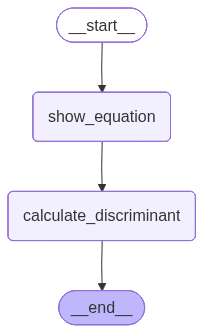

In [24]:
workflow

In [63]:
initial_state={
    'a':14,
    'b':3,
    'c':3,

}
graph_module=workflow.invoke(initial_state)

The equation is: 14x^2 + 3x + 3 = 0
